In [66]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
import scipy.stats as stats

In [67]:
df= pd.read_csv(r"C:\Users\rahul\Downloads\Student_Performance.csv")

In [65]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [46]:
df.shape

(10000, 6)

In [47]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [48]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [49]:
df.duplicated().sum()
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [50]:
print(f'number of duplicate rows: {df.duplicated().sum()}')
print(f'number of missing values:\n{df.isnull().sum()}')

number of duplicate rows: 127
number of missing values:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [51]:
from sklearn.preprocessing import LabelEncoder , StandardScaler

le = LabelEncoder()
df['Extracurricular Activities'] = le.fit_transform(df['Extracurricular Activities'])

In [52]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


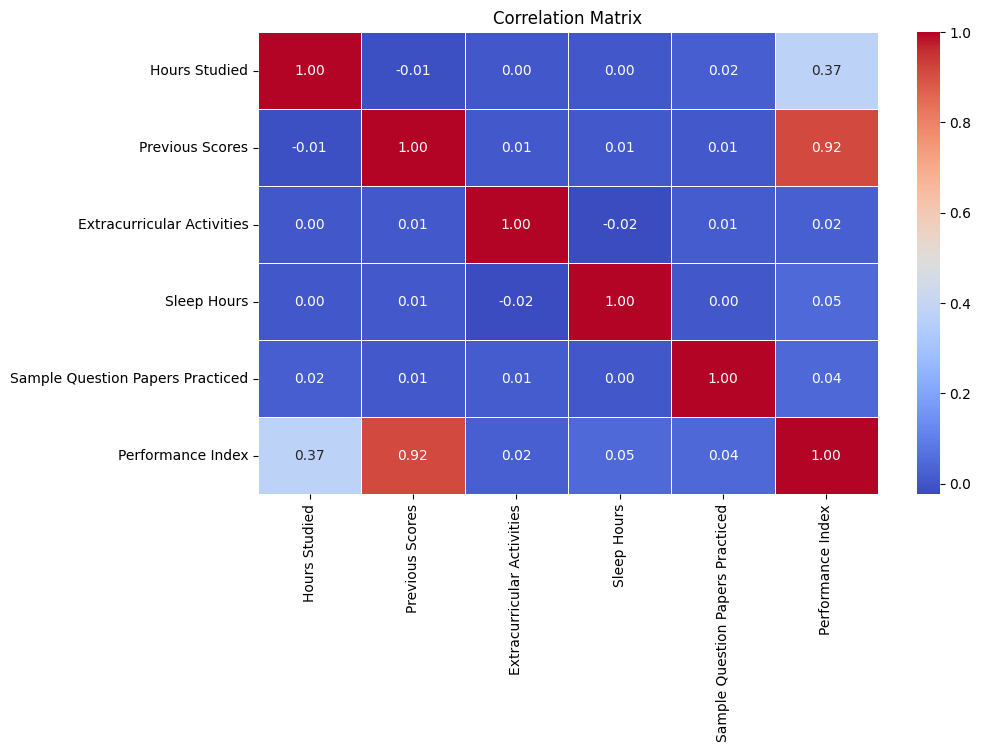

In [53]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm' , fmt=".2f", linewidths=0.5)        
plt.title('Correlation Matrix')
plt.show()

In [54]:
df.drop(columns=['Extracurricular Activities','Sleep Hours','Sample Question Papers Practiced'], axis=1,inplace=True)


In [55]:
df.head()

,Hours Studied,Previous Scores,Performance Index
0,7,99,91.0
1,4,82,65.0
2,8,51,45.0
3,5,52,36.0
4,7,75,66.0


In [56]:
df.describe()

,Hours Studied,Previous Scores,Performance Index
count,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,55.224800
std,2.589309,17.343152,19.212558
min,1.000000,40.000000,10.000000
25%,3.000000,54.000000,40.000000
50%,5.000000,69.000000,55.000000
75%,7.000000,85.000000,71.000000
max,9.000000,99.000000,100.000000


In [57]:
# # Y =df ['Performance Index']
# # X = df.drop('Performance Index', axis=1)

# # scalar = StandardScaler()
# # X_scaled = pd.DataFrame(scalar.fit_transform(X), columns=X.columns)

# # from sklearn.model_selection import train_test_split as tts
# # X_train, X_test, Y_train, Y_test = tts(X_scaled, Y, test_size=0.3, random_state=42)

# # print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split

# # Split features and target
# Y = df['Performance Index']
# X = df.drop('Performance Index', axis=1)

# # Scale the features
# scaler = StandardScaler()
# X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# # Split into training and testing sets
# X_train, X_test, Y_train, Y_test = train_test_split(
#     X_scaled, Y, test_size=0.3, random_state=42
# )

# # Print shapes
# print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)


In [58]:
# feature = 'Previous Scores'
# X_single_train = X_train[[feature]]
# X_single_test = X_test[[feature]]

# lr = LinearRegression()
# lr.fit(X_single_train, Y_train)  

# Y_pred = lr.predict(X_single_test)

# plt.scatter(X_single_test, Y_test, color='blue', label='Actual')
# plt.plot(X_single_test, Y_pred, color='red', label='Predicted')  
# plt.title('Single Linear Regression')
# plt.xlabel(feature)
# plt.ylabel('Performance Index') 
# plt.legend()
# plt.grid(True)
# plt.show()

# r2_single = r2_score(Y_test, Y_pred)
# print(f'Single Linear Regression R²: {r2_single:.4f}')
# mse_single = mean_squared_error(Y_test, Y_pred)
# print(f'Single Linear Regression MSE: {mse_single:.4f}')

In [59]:
# lr_multi = LinearRegression()
# lr_multi.fit(X_train, Y_train)

# Y_multi_pred = lr_multi.predict(X_test)

# plt.scatter(Y_test, Y_multi_pred,alpha=0.5, color='green')
# plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()],color= 'red', )
# plt.title('Multiple Linear Regression')
# plt.xlabel('Actual Performance Index')  
# plt.ylabel('Predicted Performance Index')   
# plt.grid(True)
# plt.show()

# r2_multi = r2_score(Y_test, Y_multi_pred)
# mse_multi = mean_squared_error(Y_test, Y_multi_pred)

# print(f'Multiple Linear Regression R²: {r2_multi:.4f}')
# print(f'Multiple Linear Regression MSE: {mse_multi:.4f}')

In [60]:
# import pandas as pd
# import numpy as np

# # Example new data
# new_data = pd.DataFrame({
#     'Previous Scores': [60, 75, 90]
# })

# # Predict
# new_predictions = lr.predict(new_data)

# # Round to 1 decimal place
# new_predictions = np.round(new_predictions, 1)

# # Combine results
# results = new_data.copy()
# results['Predicted Performance Index'] = new_predictions

# print(results)


In [61]:
# # Import necessary libraries
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import r2_score, mean_squared_error
# import numpy as np

# # Suppose your dataset is already loaded in a DataFrame called df
# # Example: df = pd.read_csv('student_scores.csv')

# # Step 1: Split features (X) and target (Y)
# X = df[['Hours Studied', 'Previous Scores']]
# Y = df['Performance Index']

# # Step 2: Scale features (optional but recommended)
# scaler = StandardScaler()
# X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# # Step 3: Split into training and testing sets
# X_train, X_test, Y_train, Y_test = train_test_split(
#     X_scaled, Y, test_size=0.3, random_state=42
# )

# # Step 4: Train the Linear Regression model
# lr = LinearRegression()
# lr.fit(X_train, Y_train)

# # Step 5: Predict on the test data
# Y_pred = lr.predict(X_test)

# # Step 6: Evaluate model performance
# print("R² Score:", round(r2_score(Y_test, Y_pred), 3))
# print("MSE:", round(mean_squared_error(Y_test, Y_pred), 3))

# # Step 7: Predict new student scores
# new_students = pd.DataFrame({
#     'Hours Studied': [4, 6, 8],
#     'Previous Scores': [70, 80, 90]
# })

# # Scale new data using same scaler
# new_students_scaled = scaler.transform(new_students)

# # Predict and round to 1 decimal
# new_predictions = np.round(lr.predict(new_students_scaled), 1)

# # Display results
# results = new_students.copy()
# results['Predicted Performance Index'] = new_predictions
# print(results)


In [62]:
# new_students = pd.DataFrame({
#     'Hours Studied': [4, 6, 8],
#     'Previous Scores': [70, 80, 90]
# })
# print (new_students)

Shapes:
(7000, 2) (3000, 2) (7000,) (3000,)


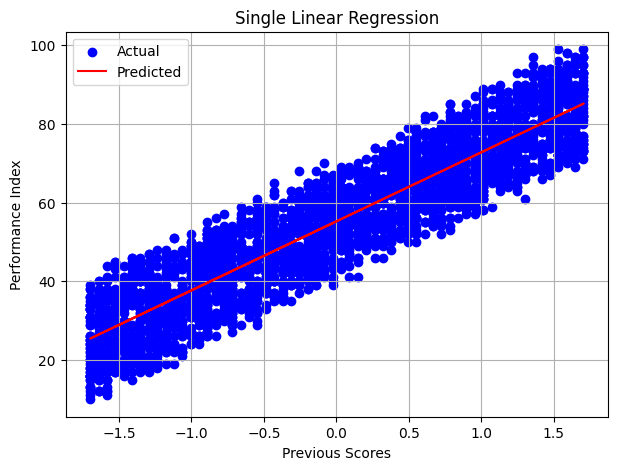

Single Linear Regression R²: 0.8417
Single Linear Regression MSE: 58.5939


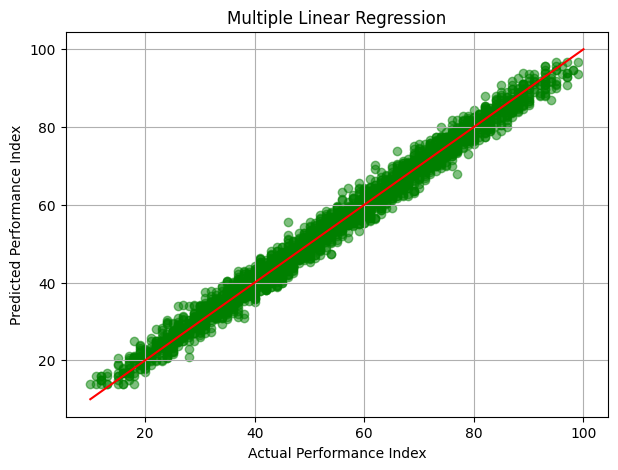

Multiple Linear Regression R²: 0.9859
Multiple Linear Regression MSE: 5.2013

📊 Predicted Performance for New Students:
   Hours Studied  Previous Scores  Predicted Performance Index
0              4               70                         53.0
1              6               80                         68.9
2              8               90                         84.8
✅ Model and Scaler saved successfully!
📁 Files created: 'student_model.pkl' and 'scaler.pkl'


In [63]:
# ============================================
# 📘 LINEAR REGRESSION MODEL FOR STUDENT SCORE
# ============================================

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import joblib

# -------------------------------
# Step 1: Split features and target
# -------------------------------
Y = df['Performance Index']
X = df.drop('Performance Index', axis=1)

# -------------------------------
# Step 2: Scale the features
# -------------------------------
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# -------------------------------
# Step 3: Split into training and testing sets
# -------------------------------
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.3, random_state=42
)

print("Shapes:")
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)
print("="*50)

# -------------------------------
# Step 4: Single Linear Regression (using one feature)
# -------------------------------
feature = 'Previous Scores'
X_single_train = X_train[[feature]]
X_single_test = X_test[[feature]]

lr = LinearRegression()
lr.fit(X_single_train, Y_train)
Y_pred = lr.predict(X_single_test)

# Visualization - Single Linear Regression
plt.figure(figsize=(7, 5))
plt.scatter(X_single_test, Y_test, color='blue', label='Actual')
plt.plot(X_single_test, Y_pred, color='red', label='Predicted')
plt.title('Single Linear Regression')
plt.xlabel(feature)
plt.ylabel('Performance Index')
plt.legend()
plt.grid(True)
plt.show()

# Evaluation Metrics - Single Linear Regression
r2_single = r2_score(Y_test, Y_pred)
mse_single = mean_squared_error(Y_test, Y_pred)
print(f'Single Linear Regression R²: {r2_single:.4f}')
print(f'Single Linear Regression MSE: {mse_single:.4f}')
print("="*50)

# -------------------------------
# Step 5: Multiple Linear Regression (using all features)
# -------------------------------
lr_multi = LinearRegression()
lr_multi.fit(X_train, Y_train)
Y_multi_pred = lr_multi.predict(X_test)

# Visualization - Multiple Linear Regression
plt.figure(figsize=(7, 5))
plt.scatter(Y_test, Y_multi_pred, alpha=0.5, color='green')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], color='red')
plt.title('Multiple Linear Regression')
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.grid(True)
plt.show()

# Evaluation Metrics - Multiple Linear Regression
r2_multi = r2_score(Y_test, Y_multi_pred)
mse_multi = mean_squared_error(Y_test, Y_multi_pred)
print(f'Multiple Linear Regression R²: {r2_multi:.4f}')
print(f'Multiple Linear Regression MSE: {mse_multi:.4f}')
print("="*50)

# -------------------------------
# Step 6: Predict Performance for New Students
# -------------------------------

# Example new data (raw values)
new_data = pd.DataFrame({
    'Hours Studied': [4, 6, 8],
    'Previous Scores': [70, 80, 90]
})

# Scale new data using same scaler (important!)
new_data_scaled = pd.DataFrame(scaler.transform(new_data), columns=new_data.columns)

# Predict using multiple regression model
new_predictions = lr_multi.predict(new_data_scaled)

# Combine results in a clean table
new_data['Predicted Performance Index'] = new_predictions.round(1)

print("\n📊 Predicted Performance for New Students:")
print(new_data)

joblib.dump(lr_multi, 'student_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model and Scaler saved successfully!")
print("📁 Files created: 'student_model.pkl' and 'scaler.pkl'")